In [1]:
import numpy as np
import pandas as pd
import sklearn

print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)

2.5.1
3.0.5
1.9.0


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(r"C:\Users\ssima\Downloads\Online_Retail.xlsx")

In [4]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df.shape

(541909, 8)

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
# Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Duplicate Rows
df.duplicated().sum()

np.int64(5268)

In [10]:
df = df.dropna(subset=["CustomerID"])
### Missing Value Handling

#- CustomerID: Rows with missing CustomerID were removed because customer identification is essential for customer segmentation.
#- Description: Missing values were replaced with "Unknown" since this column is not used in clustering.

In [11]:
df.shape

(406829, 8)

In [12]:
print("Duplicate Rows Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 5225
Duplicate Rows After: 0


In [13]:
# Data Types
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [14]:
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

In [15]:
df.drop_duplicates(inplace=True)
print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows After: 0


In [16]:
### Duplicate Removal

#Duplicate records were identified using pandas `duplicated()` and removed using `drop_duplicates()`
#to avoid repeated transactions affecting the analysis.

In [17]:
# Remove cancelled/returned transactions
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

In [18]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [19]:
average_purchase = df["TotalAmount"].mean()
print("Average Purchase Value:", average_purchase)

Average Purchase Value: 22.631499735161402


In [20]:
purchase_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

print(purchase_frequency.head())

CustomerID
12346    1
12347    7
12348    4
12349    1
12350    1
Name: InvoiceNo, dtype: int64


In [21]:
print("Average Purchase Frequency:", purchase_frequency.mean())

Average Purchase Frequency: 4.272014753342554


In [22]:
customer_ltv = df.groupby("CustomerID")["TotalAmount"].sum()

print(customer_ltv.head())

CustomerID
12346    77183.60
12347     4310.00
12348     1797.24
12349     1757.55
12350      334.40
Name: TotalAmount, dtype: float64


In [23]:
print("Average Customer Lifetime Value:", customer_ltv.mean())

Average Customer Lifetime Value: 2048.688080682342


In [24]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [25]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [26]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [27]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [28]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [29]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


In [30]:
X = rfm[["Recency", "Frequency", "Monetary"]]

In [31]:
X.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
X_scaled

array([[ 2.33457414e+00, -4.25096503e-01,  8.36301037e+00],
       [-9.05340320e-01,  3.54416797e-01,  2.51698905e-01],
       [-1.75359593e-01, -3.53398530e-02, -2.79878269e-02],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08214334e-01],
       [-8.85340848e-01,  1.52368675e+00, -3.51515172e-04],
       [-4.95351144e-01, -1.65258736e-01, -2.35311112e-02]],
      shape=(4338, 3))

In [34]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

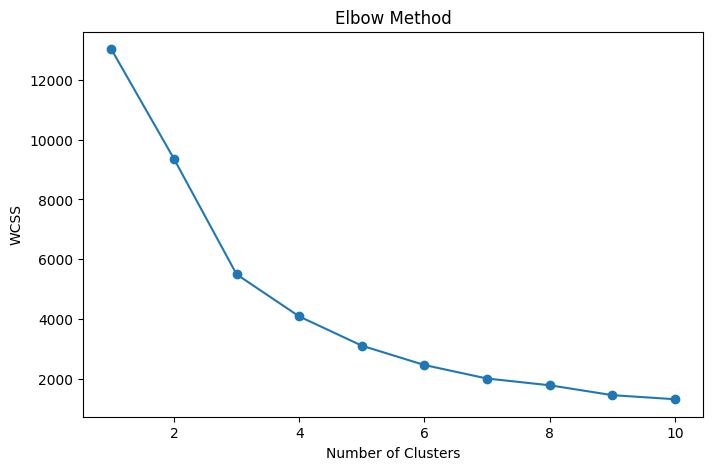

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

In [37]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


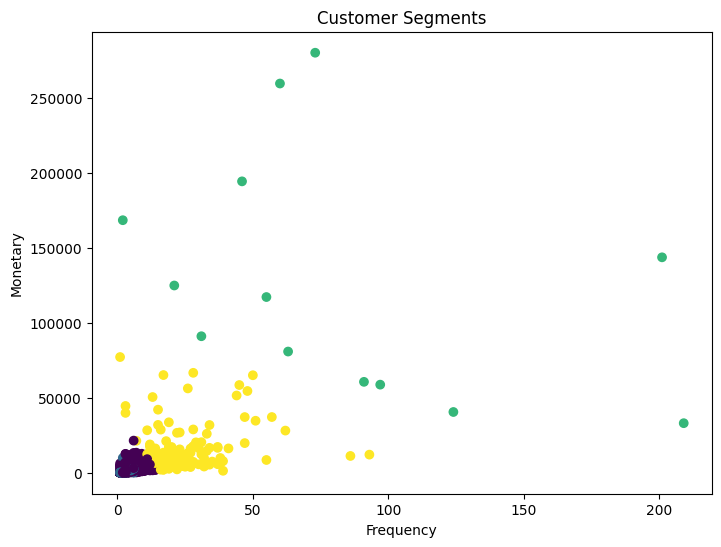

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(rfm["Frequency"],
            rfm["Monetary"],
            c=rfm["Cluster"])

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.title("Customer Segments")

plt.show()

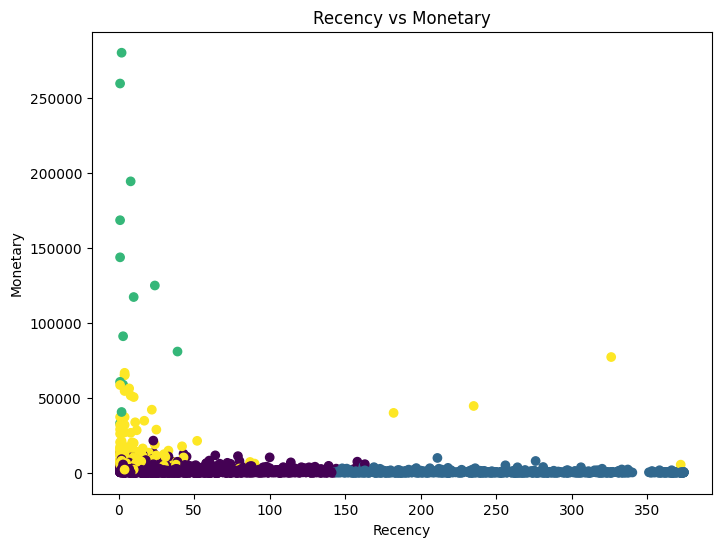

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(rfm["Recency"],
            rfm["Monetary"],
            c=rfm["Cluster"])

plt.xlabel("Recency")

plt.ylabel("Monetary")

plt.title("Recency vs Monetary")

plt.show()

In [40]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


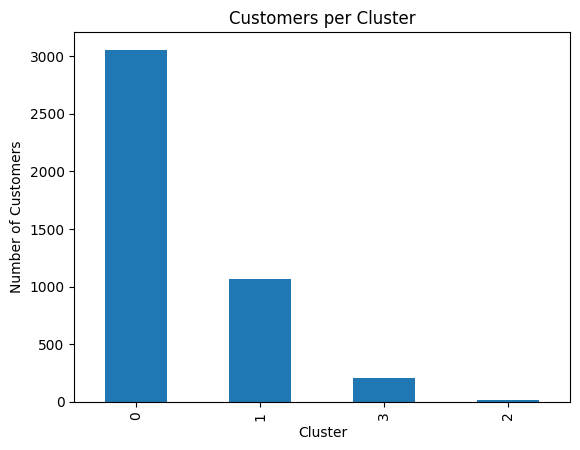

In [41]:
rfm["Cluster"].value_counts().plot(kind="bar")

plt.title("Customers per Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [42]:
#market insights
#Cluster 0
#Loyal customers
#Recommendation: Loyalty rewards
#Cluster 1
#High-value customers
#Recommendation: Premium membership and exclusive offers
#Cluster 2
#New customers
#Recommendation: Welcome coupons and onboarding emails
#Cluster 3
#At-risk customers
#Recommendation: Re-engagement campaigns and discounts

In [ ]:
#The customer segmentation analysis was successfully completed using RFM analysis and K-Means clustering.

#Four customer segments were identified based on purchasing behavior. These insights can help businesses design targeted marketing campaigns, improve customer retention, and maximize revenue.